# HATR cross-framework — Performance computazionale

Confronto del costo computazionale di HATR in River (Python) e CapyMOA (JVM via JNI) su 4 dataset: tempo di training, inferenza, throughput e crescita della dimensione modello.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), f"JAR non trovato: {HATR_JAR}\ncompilare: cd implementation/hatr-moa && mvn -o package -DskipTests"

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel -> Restart & Run All')
else:
    SIZEOF_JAR = os.path.expanduser(
        "~/.m2/repository/com/github/fracpete/sizeofag/1.1.0/sizeofag-1.1.0.jar")
    if os.path.exists(SIZEOF_JAR):
        os.environ["CAPYMOA_JVM_ARGS"] = (
            f"-Xmx8g -Xss10M -javaagent:{SIZEOF_JAR} "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
            "-XX:ErrorFile=/dev/null"
        )
    else:
        os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression
import psutil
from pympler import asizeof

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print("Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati")

Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati


## Dataset

In [2]:
MAX_INSTANCES = 17000
SYN_N, SYN_DRIFT = 17000, 5000

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', '..', 'data'))

datasets = {}
datasets["Synthetic"]         = utils.make_synthetic(n=SYN_N, drift_at=SYN_DRIFT)
datasets["Bike"]              = utils.materialize_stream(Bike(), MAX_INSTANCES)
datasets["Fried"]             = utils.materialize_stream(Fried(), MAX_INSTANCES)
datasets["Hyper"]             = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=2, magnitude_of_change=0.001,
                         noise_percentage=5),
    MAX_INSTANCES)
datasets["HyperFast"]         = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=5, magnitude_of_change=0.1,
                         noise_percentage=10),
    MAX_INSTANCES)
datasets["FriedDrift"]        = utils.make_fried_drift(
    n=MAX_INSTANCES, drift_at=MAX_INSTANCES // 2)
datasets["RBFReg"]            = utils.make_rbf_regression(
    n=MAX_INSTANCES, drift_at=MAX_INSTANCES // 2)
datasets["ElectricityDemand"] = utils.load_electricity_demand(
    os.path.join(DATA_DIR, 'electricity.arff'), max_instances=MAX_INSTANCES)

for name, (X, y, schema) in datasets.items():
    print(f"{name:<20} n={len(X):>6}  feat={X.shape[1]:>2}  y\u2208[{y.min():.2f}, {y.max():.2f}]")

Synthetic            n= 17000  feat= 5  y∈[-14.29, 15.55]
Bike                 n= 17000  feat=12  y∈[1.00, 977.00]
Fried                n= 17000  feat=10  y∈[-1.23, 30.05]
Hyper                n= 17000  feat=10  y∈[93.98, 677.42]
HyperFast            n= 17000  feat=10  y∈[-4117.78, 11925.45]
FriedDrift           n= 17000  feat=10  y∈[-0.69, 30.15]
RBFReg               n= 17000  feat=10  y∈[-13.18, 16.44]
ElectricityDemand    n= 17000  feat= 7  y∈[0.00, 0.94]


## Parametri

In [3]:
BASE = dict(grace_period=50, delta=1e-7, tau=0.05, model_selector_decay=0.95,
            drift_window_threshold=500, switch_significance=0.05,
            min_samples_split=5, adwin_delta=0.0001, learning_ratio=0.01, seed=0)

CONFIGS = {
    "deterministic (mean, no-bootstrap)": dict(leaf_prediction="mean",     bootstrap_sampling=False),
    "default (adaptive, bootstrap)":      dict(leaf_prediction="adaptive", bootstrap_sampling=True),
}

SCALE = True

## Esecuzione

In [4]:
SAMPLE_EVERY = 500
PERF_CONFIG  = "default (adaptive, bootstrap)"
cfg = CONFIGS[PERF_CONFIG]

# warmup JVM: evita che il JIT di HotSpot penalizzi il primo dataset (Bike)
_w_X, _w_y, _w_schema = next(iter(datasets.values()))
utils.prequential_eval(_w_X[:10000], _w_y[:10000], 'capy', cfg, BASE, schema=_w_schema, scale=SCALE)

rows = []
for ds_name, (X, y, schema) in datasets.items():
    n = len(X)
    _, r_model, rt_p, rt_t, _ = utils.prequential_eval(X, y, 'river', cfg, BASE, time_algo=True)
    _, c_learner, ct_p, ct_t, _ = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, time_algo=True)
    r_mb = utils.river_model_mb(r_model)
    c_mb = utils.capy_model_mb(c_learner)
    rows.append(dict(dataset=ds_name, framework="River", n=n,
                     train_s=rt_t, predict_s=rt_p, total_s=rt_t + rt_p,
                     inst_per_s=n / (rt_t + rt_p), model_MB=r_mb))
    rows.append(dict(dataset=ds_name, framework="CapyMOA", n=n,
                     train_s=ct_t, predict_s=ct_p, total_s=ct_t + ct_p,
                     inst_per_s=n / (ct_t + ct_p), model_MB=c_mb))
    print(f"  {ds_name:<10} River {rt_t+rt_p:6.2f}s {r_mb:.3f} MB  |  CapyMOA {ct_t+ct_p:6.2f}s {c_mb:.4f} MB")

perf = pd.DataFrame(rows)
speedup = (perf[perf.framework == "CapyMOA"].set_index("dataset")["inst_per_s"] /
           perf[perf.framework == "River"].set_index("dataset")["inst_per_s"])
perf["speedup_vs_river"] = perf["dataset"].map(speedup)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
perf

  Synthetic  River   1.28s 3.485 MB  |  CapyMOA   0.23s 0.4493 MB
  Bike       River   1.39s 1.457 MB  |  CapyMOA   0.39s 0.3459 MB
  Fried      River   2.55s 3.866 MB  |  CapyMOA   0.42s 0.2726 MB
  Hyper      River   2.90s 0.873 MB  |  CapyMOA   0.25s 0.1711 MB
  HyperFast  River   2.78s 0.205 MB  |  CapyMOA   0.30s 0.1435 MB
  FriedDrift River   2.90s 5.810 MB  |  CapyMOA   0.44s 0.8402 MB
  RBFReg     River   2.65s 1.586 MB  |  CapyMOA   0.30s 0.6841 MB
  ElectricityDemand River   0.97s 0.829 MB  |  CapyMOA   0.25s 0.0564 MB


,dataset,framework,n,train_s,predict_s,total_s,inst_per_s,model_MB,speedup_vs_river
0,Synthetic,River,17000,1.2111,0.0687,1.2798,13283.2091,3.4848,5.6507
1,Synthetic,CapyMOA,17000,0.0985,0.1280,0.2265,75058.8828,0.4493,5.6507
2,Bike,River,17000,1.3347,0.0602,1.3949,12187.1083,1.4575,3.5564
3,Bike,CapyMOA,17000,0.2766,0.1157,0.3922,43342.7846,0.3459,3.5564
4,Fried,River,17000,2.4754,0.0755,2.5508,6664.5537,3.8660,6.0424
5,Fried,CapyMOA,17000,0.3624,0.0598,0.4221,40270.1629,0.2726,6.0424
6,Hyper,River,17000,2.8336,0.0682,2.9017,5858.5702,0.8731,11.7788
7,Hyper,CapyMOA,17000,0.1872,0.0591,0.2464,69007.1411,0.1711,11.7788
8,HyperFast,River,17000,2.7334,0.0447,2.7782,6119.1519,0.2055,9.2531
9,HyperFast,CapyMOA,17000,0.2412,0.0591,0.3002,56620.9147,0.1435,9.2531


## Grafici

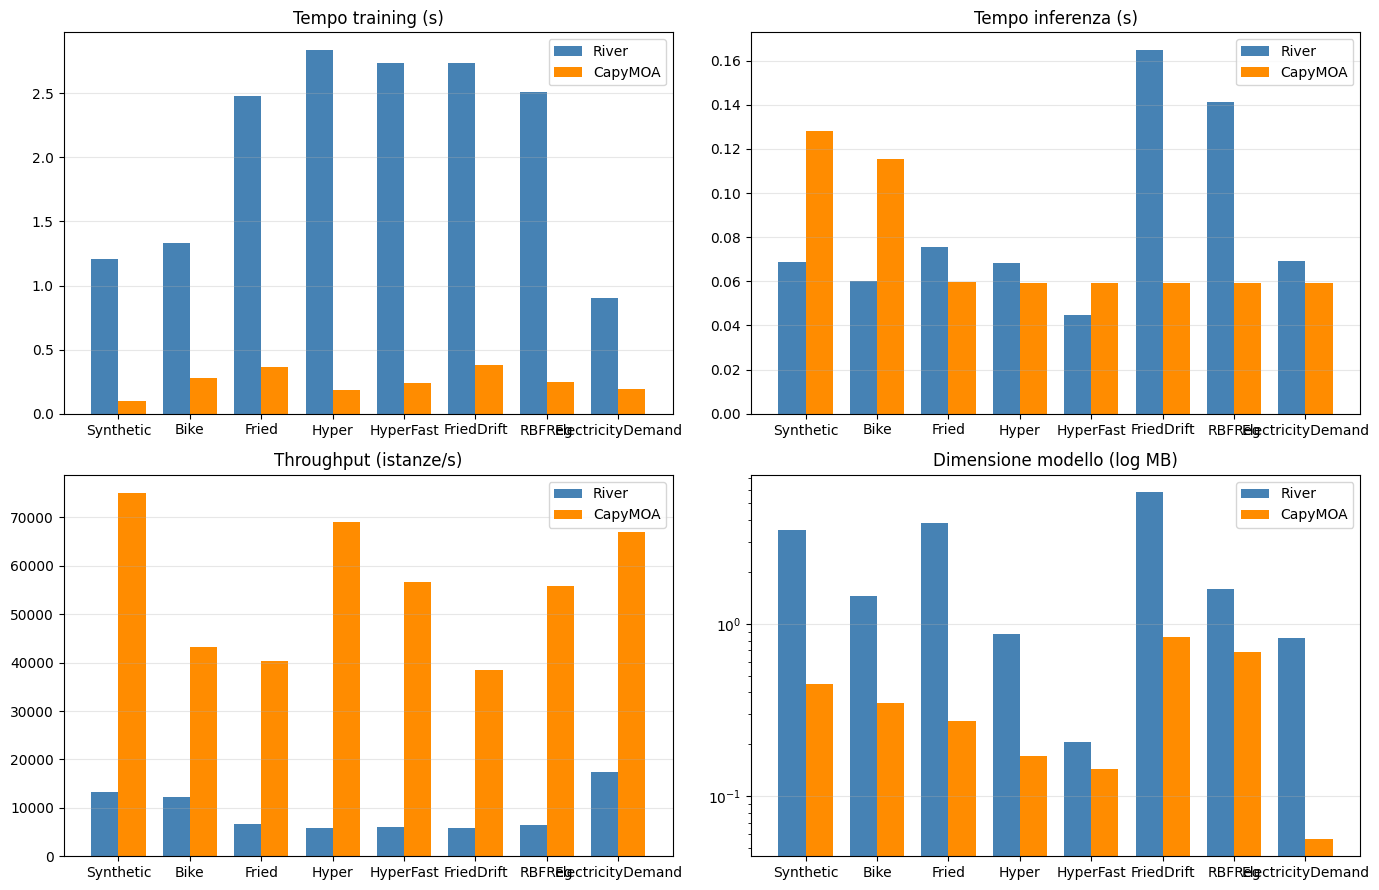

          dataset framework  train_s  predict_s  inst_per_s  model_MB  speedup_vs_river
        Synthetic     River   1.2111     0.0687  13283.2091    3.4848            5.6507
        Synthetic   CapyMOA   0.0985     0.1280  75058.8828    0.4493            5.6507
             Bike     River   1.3347     0.0602  12187.1083    1.4575            3.5564
             Bike   CapyMOA   0.2766     0.1157  43342.7846    0.3459            3.5564
            Fried     River   2.4754     0.0755   6664.5537    3.8660            6.0424
            Fried   CapyMOA   0.3624     0.0598  40270.1629    0.2726            6.0424
            Hyper     River   2.8336     0.0682   5858.5702    0.8731           11.7788
            Hyper   CapyMOA   0.1872     0.0591  69007.1411    0.1711           11.7788
        HyperFast     River   2.7334     0.0447   6119.1519    0.2055            9.2531
        HyperFast   CapyMOA   0.2412     0.0591  56620.9147    0.1435            9.2531
       FriedDrift     River   2.

In [5]:
ds_order = list(datasets.keys())
def vals(metric, fw):
    return [perf[(perf.dataset == d) & (perf.framework == fw)][metric].values[0] for d in ds_order]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
panels = [
    ("train_s",    "Tempo training (s)",         False),
    ("predict_s",  "Tempo inferenza (s)",         False),
    ("inst_per_s", "Throughput (istanze/s)",      False),
    ("model_MB",   "Dimensione modello (log MB)", True),
]
for ax, (metric, title, log_scale) in zip(axes.ravel(), panels):
    rv, cm = vals(metric, "River"), vals(metric, "CapyMOA")
    xpos = np.arange(len(ds_order)); wbar = 0.38
    ax.bar(xpos - wbar/2, rv, wbar, label="River",   color="steelblue")
    ax.bar(xpos + wbar/2, cm, wbar, label="CapyMOA", color="darkorange")
    if log_scale:
        ax.set_yscale("log")
    ax.set_xticks(xpos); ax.set_xticklabels(ds_order); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(perf[["dataset", "framework", "train_s", "predict_s", "inst_per_s",
            "model_MB", "speedup_vs_river"]].to_string(index=False))

## Crescita dimensione modello

Synthetic: River 4.084 MB | CapyMOA 0.7634 MB
Bike: River 0.837 MB | CapyMOA 0.1747 MB
Fried: River 6.931 MB | CapyMOA 1.0828 MB
Hyper: River 8.501 MB | CapyMOA 1.3004 MB
HyperFast: River 0.932 MB | CapyMOA 0.1413 MB
FriedDrift: River 3.143 MB | CapyMOA 0.4818 MB
RBFReg: River 7.263 MB | CapyMOA 1.1024 MB
ElectricityDemand: River 0.377 MB | CapyMOA 0.1026 MB


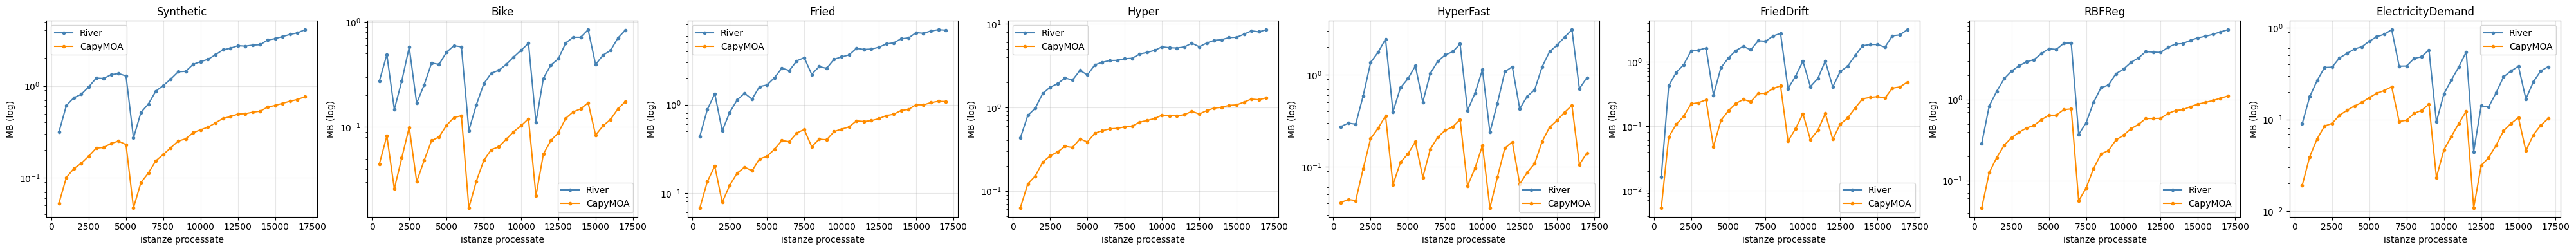

In [6]:
cfg = CONFIGS["deterministic (mean, no-bootstrap)"]
traces = {}
for ds_name, (X, y, schema) in datasets.items():
    _, _, _, _, tr_r = utils.prequential_eval(X, y, 'river', cfg, BASE, scale=SCALE, sample_every=SAMPLE_EVERY)
    _, _, _, _, tr_c = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, scale=SCALE, sample_every=SAMPLE_EVERY)
    traces[ds_name] = {"River": tr_r, "CapyMOA": tr_c}
    print(f"{ds_name}: River {tr_r[-1]['model_MB']:.3f} MB | CapyMOA {tr_c[-1]['model_MB']:.4f} MB")

colors  = {"River": "steelblue", "CapyMOA": "darkorange"}
ds_list = list(datasets.keys())

fig, axes = plt.subplots(1, len(ds_list), figsize=(5 * len(ds_list), 4))
for ax, ds_name in zip(axes, ds_list):
    for fw in ("River", "CapyMOA"):
        t  = traces[ds_name][fw]
        ns = [p["n"]        for p in t]
        vs = [p["model_MB"] for p in t]
        ax.plot(ns, vs, label=fw, color=colors[fw], marker="o", markersize=3)
    ax.set_yscale("log")
    ax.set_title(ds_name)
    ax.set_xlabel("istanze processate")
    ax.set_ylabel("MB (log)")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()